# Hourly Ozone: Covariance Structure, Pooled ACF, and PAR Model

**데이터 구조**: 하루 8슬롯 (연속), 다음날까지 ~16h 갭  
→ 연속 time series로 취급하면 lag-1이 1h 또는 17h로 혼재 → **n×8 행렬**로 분리

**분석 흐름**:
1. Block 1 — 8×8 공분산 행렬 → Toeplitz 체크  
2. Block 2 — Pooled within-day ACF  
3. Block 3 — 왜 1과 2가 같은지 + PAR (Periodic AR) 모델

In [12]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

warnings.filterwarnings('ignore')

sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")
from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed

# ── Config ────────────────────────────────────────────────────────────────────
YEARS         = ['2022', '2023', '2024', '2025']
MONTHS        = [4, 5, 6, 7, 8, 9]
LAT_RANGE     = [-3.0, 2.0]
LON_RANGE     = [121.0, 131.0]
MM_COND       = 10
SLOTS_PER_DAY = 8

OUT_DIR = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/seasonal_ar/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup done.")

Setup done.


In [13]:
# ── Data loading (seasonal_ar_test_local_033026.py 와 동일) ───────────────────

def load_spatial_means():
    data_loader = load_data_dynamic_processed(config.mac_data_load_path)
    records = []
    for yr in YEARS:
        for mo in MONTHS:
            print(f"  Loading {yr}-{mo:02d}...", flush=True)
            df_map, _, _, _ = data_loader.load_maxmin_ordered_data_bymonthyear(
                lat_lon_resolution=[1, 1], mm_cond_number=MM_COND,
                years_=[yr], months_=[mo],
                lat_range=LAT_RANGE, lon_range=LON_RANGE,
                is_whittle=False)
            sorted_keys = sorted(df_map.keys())
            n_days = len(sorted_keys) // SLOTS_PER_DAY
            for d_idx in range(n_days):
                day_keys = sorted_keys[d_idx * SLOTS_PER_DAY:(d_idx + 1) * SLOTS_PER_DAY]
                for slot, key in enumerate(day_keys):
                    df = df_map[key]
                    o3    = pd.to_numeric(df['ColumnAmountO3'], errors='coerce').dropna()
                    hours = pd.to_numeric(df['Hours_elapsed'],  errors='coerce').dropna()
                    if len(o3) == 0 or len(hours) == 0:
                        continue
                    records.append({
                        'year': int(yr), 'month': mo, 'day_idx': d_idx,
                        'slot': slot,
                        'hours_elapsed': float(hours.median()),
                        'spatial_mean':  float(o3.mean()),
                        'n_obs':         int(len(o3)),
                    })
    df_out = pd.DataFrame(records).sort_values('hours_elapsed').reset_index(drop=True)
    df_out['spatial_mean_c'] = df_out.groupby(['year', 'month'])['spatial_mean'].transform(
        lambda x: x - x.mean())
    return df_out


def build_hourly_matrix(df):
    """Returns Y (n_days, 8) — centered spatial means."""
    day_order = (df.groupby(['year', 'month', 'day_idx'])['hours_elapsed']
                   .min().reset_index().sort_values('hours_elapsed'))
    mat_rows, day_labels = [], []
    for _, row in day_order.iterrows():
        yr, mo, d_idx = int(row['year']), int(row['month']), int(row['day_idx'])
        sub = df[(df['year'] == yr) & (df['month'] == mo) & (df['day_idx'] == d_idx)]
        vec = np.full(SLOTS_PER_DAY, np.nan)
        for _, r in sub.iterrows():
            vec[int(r['slot'])] = r['spatial_mean_c']
        mat_rows.append(vec)
        day_labels.append((yr, mo, d_idx))
    return np.array(mat_rows), day_labels


print("Loading data...")
df = load_spatial_means()
Y, day_labels = build_hourly_matrix(df)
n_days, n_slots = Y.shape
print(f"Y shape: {Y.shape}  (n_days={n_days}, slots_per_day={n_slots})")
print(f"NaN 비율: {np.isnan(Y).mean()*100:.1f}%")

Loading data...
  Loading 2022-04...
--- Global Monthly Mean for 2022-4: 235.4573 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  Loading 2022-05...
--- Global Monthly Mean for 2022-5: 242.8715 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  Loading 2022-06...
--- Global Monthly Mean for 2022-6: 246.6272 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  Loading 2022-07...
--- Global Monthly Mean for 2022-7: 250.6500 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  Loading 2022-08...
--- Global Monthly Mean for 2022-8: 257.3822 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  Loading 2022-09...
--- Global Monthly Mean for 2022-9: 263.5558 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  Loading 2023-04...
--- Global Monthly Mean for 2023-4: 263.5141 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  Loading 2023-05...
--- Global Monthly Mean for 2023-5: 247.9414 ---
--- Generating NNS Map fo

---
## Block 1 — 8×8 공분산 행렬과 Toeplitz 체크

### 표기
- $Y \in \mathbb{R}^{n \times 8}$ : $n$일치 데이터, 각 행은 하루의 8슬롯 공간평균 (year-month 내 center됨)
- $Y[d, h]$ : $d$번째 날, $h$번째 슬롯 ($h = 0, \ldots, 7$)

### 표본 공분산 행렬

$$\hat{C}[h_1, h_2] = \frac{1}{n} \sum_{d=1}^{n} Y[d,\, h_1] \cdot Y[d,\, h_2]$$

(이미 centered이므로 mean 빼기 불필요)

결과는 **8×8 행렬**. 각 원소는 "$h_1$슬롯과 $h_2$슬롯이 $n$일에 걸쳐 얼마나 함께 움직이는가".

### Toeplitz 조건

$$\hat{C}[h_1, h_2] = c(|h_1 - h_2|) \quad \forall\, h_1, h_2$$

즉, **슬롯 간 거리(시간 차)에만 의존**하고 절대 위치에는 의존하지 않아야 함.  
→ 같은 오프-대각선 $k$의 원소들이 모두 같아야 함.

**정량 체크**: 각 대각선 $k=0,\ldots,7$에 대해
$$\text{diag}_k = \{\hat{C}[h, h+k] : h = 0, \ldots, 7-k\}$$
의 표준편차가 0에 가까운지 확인.

In [14]:
# ── Block 1: 8×8 공분산 행렬 ─────────────────────────────────────────────────

def sample_cov_matrix(Y):
    """
    8×8 표본 공분산 행렬.
    NaN이 있는 날(행)은 해당 원소쌍에서만 제외 (pairwise complete obs).
    """
    n_slots = Y.shape[1]
    C = np.full((n_slots, n_slots), np.nan)
    for h1 in range(n_slots):
        for h2 in range(n_slots):
            mask = np.isfinite(Y[:, h1]) & np.isfinite(Y[:, h2])
            if mask.sum() > 1:
                C[h1, h2] = np.mean(Y[mask, h1] * Y[mask, h2])  # centered이므로 곱의 평균 = 공분산
    return C


def toeplitz_check(C):
    """
    각 오프-대각선 k에 대해:
      - 원소들의 평균, 표준편차
      - std/mean (변동계수) → 0에 가까울수록 Toeplitz에 가까움
    """
    n = C.shape[0]
    rows = []
    for k in range(n):
        diag_vals = np.array([C[h, h+k] for h in range(n-k) if np.isfinite(C[h, h+k])])
        if len(diag_vals) == 0:
            continue
        mean_val = diag_vals.mean()
        std_val  = diag_vals.std()
        cv       = std_val / abs(mean_val) if abs(mean_val) > 1e-10 else np.nan
        rows.append({
            'lag_k':    k,
            'n_elems':  len(diag_vals),
            'mean':     round(mean_val, 4),
            'std':      round(std_val,  4),
            'CV=std/|mean|': round(cv, 4) if np.isfinite(cv) else np.nan,
            'values':   np.round(diag_vals, 4).tolist(),
        })
    return pd.DataFrame(rows)


C = sample_cov_matrix(Y)
df_toep = toeplitz_check(C)

print("8×8 표본 공분산 행렬 C:")
print(pd.DataFrame(C, columns=[f'h{i}' for i in range(8)],
                       index=[f'h{i}' for i in range(8)]).round(4).to_string())
print("\nToeplitz 체크 (각 대각선별):")
print(df_toep[['lag_k','n_elems','mean','std','CV=std/|mean|','values']].to_string(index=False))

8×8 표본 공분산 행렬 C:
        h0      h1      h2       h3       h4      h5      h6       h7
h0  9.5774  9.3200  9.0561   8.5924   8.2279  8.3671  7.9735   7.8443
h1  9.3200  9.4770  9.4561   9.0875   8.6797  8.5863  7.9823   7.1971
h2  9.0561  9.4561  9.7343   9.5120   9.0663  8.7932  8.0064   6.6285
h3  8.5924  9.0875  9.5120  11.4625  14.1561  9.0948  7.9982   6.3424
h4  8.2279  8.6797  9.0663  14.1561  22.4260  9.6878  8.3772   6.7723
h5  8.3671  8.5863  8.7932   9.0948   9.6878  9.1841  8.7522   8.0692
h6  7.9735  7.9823  8.0064   7.9982   8.3772  8.7522  9.0155   8.9119
h7  7.8443  7.1971  6.6285   6.3424   6.7723  8.0692  8.9119  12.2119

Toeplitz 체크 (각 대각선별):
 lag_k  n_elems    mean    std  CV=std/|mean|                                                            values
     0        8 11.6361 4.2158         0.3623 [9.5774, 9.477, 9.7343, 11.4625, 22.426, 9.1841, 9.0155, 12.2119]
     1        7  9.9709 1.7363         0.1741            [9.32, 9.4561, 9.512, 14.1561, 9.6878, 8.7522, 8.

Font 'default' does not have a glyph for '\uacf5' [U+acf5], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ubd84' [U+bd84], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc0b0' [U+c0b0], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ud589' [U+d589], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ub82c' [U+b82c], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uacf5' [U+acf5], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ubd84' [U+bd84], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc0b0' [U+c0b0], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ud589' [U+d589], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ub82c' [U+b82c], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uacf5' [U+acf5], 

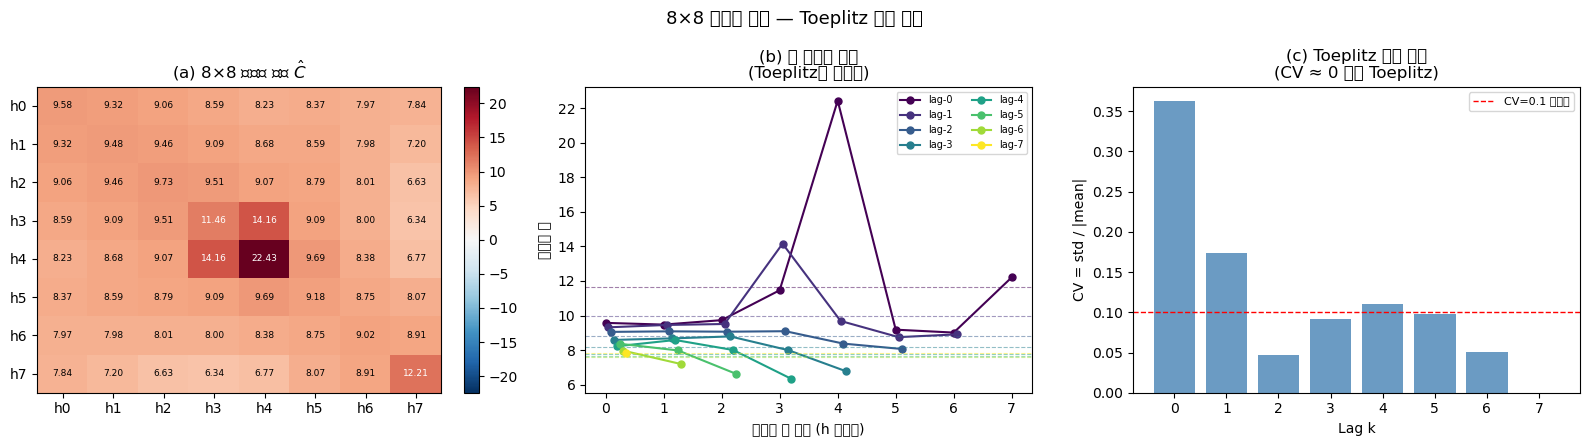

Saved: hourly_cov_toeplitz.png


In [15]:
# ── Block 1: 시각화 ───────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('8×8 공분산 행렬 — Toeplitz 구조 체크', fontsize=13)

slot_labels = [f'h{i}' for i in range(8)]

# (a) 공분산 행렬 heatmap
ax = axes[0]
vmax = np.nanmax(np.abs(C))
im = ax.imshow(C, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(8)); ax.set_xticklabels(slot_labels)
ax.set_yticks(range(8)); ax.set_yticklabels(slot_labels)
ax.set_title('(a) 8×8 공분산 행렬 $\\hat{C}$')
plt.colorbar(im, ax=ax, fraction=0.046)
# 각 셀에 값 표시
for i in range(8):
    for j in range(8):
        if np.isfinite(C[i,j]):
            ax.text(j, i, f'{C[i,j]:.2f}', ha='center', va='center', fontsize=6.5,
                    color='white' if abs(C[i,j]) > vmax*0.5 else 'black')

# (b) 각 대각선의 원소들 (Toeplitz이면 같아야 함)
ax = axes[1]
colors = plt.cm.viridis(np.linspace(0, 1, 8))
for k in range(8):
    diag_vals = [C[h, h+k] for h in range(8-k) if np.isfinite(C[h, h+k])]
    x_pos = np.arange(len(diag_vals)) + k * 0.05  # slight offset for visibility
    ax.plot(x_pos, diag_vals, 'o-', color=colors[k], label=f'lag-{k}', markersize=5)
    ax.axhline(np.mean(diag_vals), ls='--', color=colors[k], lw=0.8, alpha=0.5)
ax.set_xlabel('대각선 내 위치 (h 인덱스)')
ax.set_ylabel('공분산 값')
ax.set_title('(b) 각 대각선 원소\n(Toeplitz면 수평선)')
ax.legend(fontsize=7, ncol=2)

# (c) CV per diagonal (Toeplitz 이탈 정도)
ax = axes[2]
cv_vals = df_toep['CV=std/|mean|'].values
ax.bar(df_toep['lag_k'], cv_vals, color='steelblue', alpha=0.8)
ax.axhline(0.1, ls='--', color='red', lw=1, label='CV=0.1 기준선')
ax.set_xlabel('Lag k')
ax.set_ylabel('CV = std / |mean|')
ax.set_title('(c) Toeplitz 이탈 정도\n(CV ≈ 0 이면 Toeplitz)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'hourly_cov_toeplitz.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: hourly_cov_toeplitz.png")

---
## Block 2 — Pooled Within-day ACF

각 날 $d$에 대해 길이-8 벡터의 자기공분산 함수(ACF)를 구한 뒤 $n$일에 걸쳐 평균.

### Pooled autocovariance (lag $k$)

$$\hat{\gamma}(k) = \frac{1}{\displaystyle\sum_{d=1}^{n} (8-k - m_d)} \sum_{d=1}^{n} \sum_{h=0}^{7-k} Y[d,\,h] \cdot Y[d,\,h+k]$$

여기서 $m_d$는 날 $d$에서 $h$ 또는 $h+k$가 NaN인 쌍의 수.

### Pooled ACF

$$\hat{\rho}(k) = \frac{\hat{\gamma}(k)}{\hat{\gamma}(0)}$$

### 왜 Block 1과 같은가?

Block 1의 공분산 행렬 대각선 평균과 Block 2의 pooled autocovariance가 같다:

$$\hat{\gamma}(k) = \frac{1}{8-k} \sum_{h=0}^{7-k} \hat{C}[h,\, h+k]$$

즉, **pooled ACF는 공분산 행렬의 $k$번째 대각선 원소들의 평균**이다.

- $\hat{C}[h_1, h_2]$은 $n$일 평균이고
- $\hat{\gamma}(k)$는 동일한 값을 $h$ 방향으로 한 번 더 평균낸 것

$$\underbrace{\hat{\gamma}(k)}_{\text{Block 2}} = \underbrace{\frac{1}{8-k}\sum_{h}\hat{C}[h, h+k]}_{\text{Block 1의 대각선 평균}}$$

**차이점**: Block 1은 더 많은 정보를 담음 — 대각선 내 원소들의 분산까지 볼 수 있어 Toeplitz 여부 판단 가능. Block 2는 그 평균만 요약.

In [16]:
# ── Block 2: Pooled ACF 계산 ─────────────────────────────────────────────────

def pooled_within_acf(Y):
    """
    Pooled autocovariance γ(k) and ACF ρ(k) for k=0,...,7.

    γ(k) = Σ_{d,h} Y[d,h]*Y[d,h+k]  /  N_valid(k)

    Returns dict with keys: lag, gamma, rho, n_pairs
    """
    n_days, n_slots = Y.shape
    gamma = np.zeros(n_slots)
    n_pairs = np.zeros(n_slots, dtype=int)

    for k in range(n_slots):
        total = 0.0
        count = 0
        for d in range(n_days):
            for h in range(n_slots - k):
                v1, v2 = Y[d, h], Y[d, h + k]
                if np.isfinite(v1) and np.isfinite(v2):
                    total += v1 * v2
                    count += 1
        gamma[k]   = total / count if count > 0 else np.nan
        n_pairs[k] = count

    rho = gamma / gamma[0]
    return pd.DataFrame({'lag': range(n_slots), 'gamma': gamma,
                         'rho (ACF)': rho, 'n_pairs': n_pairs})


def diagonal_means_from_C(C):
    """Block 1 공분산 행렬의 각 대각선 평균 → 이게 γ(k)와 같아야 함."""
    n = C.shape[0]
    diag_means = []
    for k in range(n):
        vals = [C[h, h+k] for h in range(n-k) if np.isfinite(C[h, h+k])]
        diag_means.append(np.mean(vals) if vals else np.nan)
    return np.array(diag_means)


df_acf = pooled_within_acf(Y)
diag_means = diagonal_means_from_C(C)

print("Pooled within-day ACF:")
print(df_acf.round(6).to_string(index=False))

print("\n검증: γ(k) vs C의 k번째 대각선 평균")
for k in range(8):
    g = df_acf.loc[k, 'gamma']
    dm = diag_means[k]
    print(f"  lag-{k}: γ(k)={g:.6f}  diag_mean={dm:.6f}  diff={abs(g-dm):.2e}")

Pooled within-day ACF:
 lag     gamma  rho (ACF)  n_pairs
   0 11.636093   1.000000     5808
   1  9.970875   0.856892     5082
   2  8.791840   0.755566     4356
   3  8.167178   0.701883     3630
   4  7.790782   0.669536     2904
   5  7.659285   0.658235     2178
   6  7.585314   0.651878     1452
   7  7.844287   0.674134      726

검증: γ(k) vs C의 k번째 대각선 평균
  lag-0: γ(k)=11.636093  diag_mean=11.636093  diff=1.78e-14
  lag-1: γ(k)=9.970875  diag_mean=9.970875  diff=4.80e-14
  lag-2: γ(k)=8.791840  diag_mean=8.791840  diff=1.07e-14
  lag-3: γ(k)=8.167178  diag_mean=8.167178  diff=1.78e-15
  lag-4: γ(k)=7.790782  diag_mean=7.790782  diff=1.95e-14
  lag-5: γ(k)=7.659285  diag_mean=7.659285  diff=7.11e-15
  lag-6: γ(k)=7.585314  diag_mean=7.585314  diff=2.66e-15
  lag-7: γ(k)=7.844287  diag_mean=7.844287  diff=6.22e-15


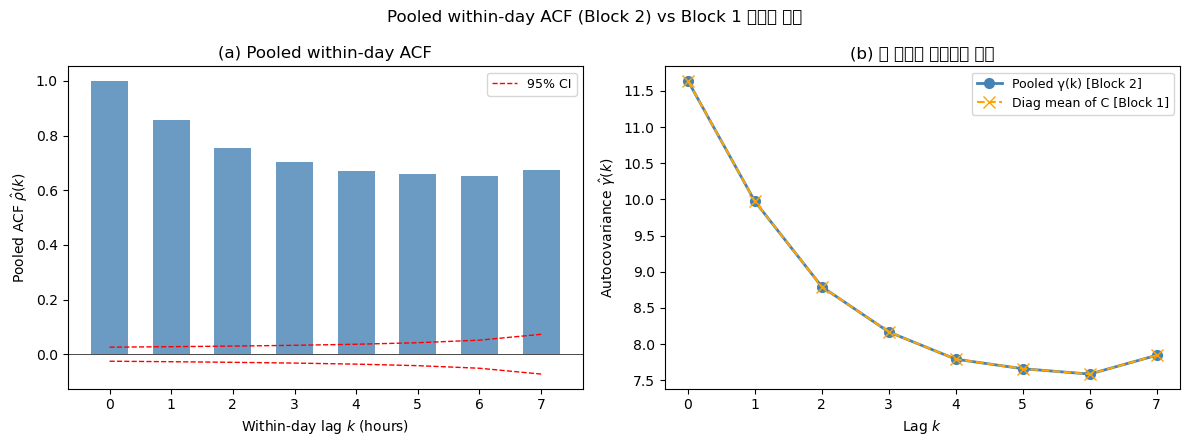

Saved: hourly_pooled_acf.png


In [17]:
# ── Block 2: 시각화 ───────────────────────────────────────────────────────────

conf = 1.96 / np.sqrt(n_days * (8 - np.arange(8)))  # pooled 95% CI

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Pooled within-day ACF (Block 2) vs Block 1 대각선 평균', fontsize=12)

# (a) Pooled ACF bar plot
ax = axes[0]
lags = df_acf['lag'].values
rho  = df_acf['rho (ACF)'].values
ax.bar(lags, rho, color='steelblue', alpha=0.8, width=0.6)
ax.plot(lags, conf,  '--', color='red', lw=1, label='95% CI')
ax.plot(lags, -conf, '--', color='red', lw=1)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Within-day lag $k$ (hours)')
ax.set_ylabel('Pooled ACF $\\hat{\\rho}(k)$')
ax.set_title('(a) Pooled within-day ACF')
ax.set_xticks(lags)
ax.legend(fontsize=9)

# (b) Block 1 대각선 평균과 비교
ax = axes[1]
ax.plot(lags, df_acf['gamma'].values, 'o-', color='steelblue',
        label='Pooled γ(k) [Block 2]', lw=2, markersize=7)
ax.plot(lags, diag_means, 'x--', color='orange', markersize=9, lw=1.5,
        label='Diag mean of C [Block 1]')
ax.set_xlabel('Lag $k$')
ax.set_ylabel('Autocovariance $\\hat{\\gamma}(k)$')
ax.set_title('(b) 두 방법이 동일함을 확인')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'hourly_pooled_acf.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: hourly_pooled_acf.png")

---
## Block 2b — Pooled Within-day PACF (AR 차수 결정)

### ACF vs PACF

| | ACF $\\hat{\\rho}(k)$ | PACF $\\hat{\\alpha}(k)$ |
|---|---|---|
| 의미 | $Y[h]$와 $Y[h+k]$의 전체 상관 (중간 lag 효과 포함) | 중간 lag 효과 **제거 후** 직접 상관 |
| AR(p) 패턴 | 기하급수적으로 천천히 감소 | **lag p 이후 딱 끊김** |
| AR 차수 결정 | 불명확 | 명확 |

### Pooled PACF 계산법 (Durbin-Levinson)

Pooled $\\hat{\\gamma}(k)$로부터 Yule-Walker 방정식을 재귀적으로 풀어 PACF를 구함:

$$\\hat{\\alpha}(1) = \\hat{\\rho}(1)$$

$$\\hat{\\alpha}(k) = \\frac{\\hat{\\rho}(k) - \\sum_{j=1}^{k-1} \\hat{\\alpha}_{k-1,j}\\, \\hat{\\rho}(k-j)}{1 - \\sum_{j=1}^{k-1} \\hat{\\alpha}_{k-1,j}\\, \\hat{\\rho}(j)}, \\quad k \\geq 2$$

이것이 AR($k$) 모델에서 마지막 계수 $\\phi_{kk}$와 동일.

### 슬롯별 cross-day PACF

각 슬롯 $h$에 대해 $n$일 시계열 $\\{Y[d, h]\\}_{d=1}^{n}$의 PACF → **며칠 전까지 유의한 cross-day 의존성이 있는가**를 슬롯마다 확인.

In [18]:
# ── Block 2b: Pooled within-day PACF (Durbin-Levinson) ──────────────────────

def durbin_levinson_pacf(gamma):
    """
    Durbin-Levinson 재귀로 PACF 계산.
    gamma: autocovariance array [γ(0), γ(1), ..., γ(p)]
    Returns PACF array of same length (index 0 = lag 0, always 1.0).
    """
    rho = gamma / gamma[0]  # ACF
    p = len(rho) - 1
    pacf = np.zeros(p + 1)
    pacf[0] = 1.0

    phi = np.zeros((p + 1, p + 1))  # phi[k, j] = AR(k) j번째 계수

    for k in range(1, p + 1):
        # numerator: ρ(k) - Σ_{j=1}^{k-1} φ_{k-1,j} * ρ(k-j)
        num = rho[k] - sum(phi[k-1, j] * rho[k-j] for j in range(1, k))
        # denominator: 1 - Σ_{j=1}^{k-1} φ_{k-1,j} * ρ(j)
        den = 1.0   - sum(phi[k-1, j] * rho[j]   for j in range(1, k))

        if abs(den) < 1e-12:
            pacf[k] = np.nan
            continue

        phi[k, k] = num / den
        pacf[k]   = phi[k, k]

        # update lower-order coefficients
        for j in range(1, k):
            phi[k, j] = phi[k-1, j] - phi[k, k] * phi[k-1, k-j]

    return pacf


gamma_vals = df_acf['gamma'].values
pacf_vals  = durbin_levinson_pacf(gamma_vals)
acf_vals   = df_acf['rho (ACF)'].values

print('Pooled within-day ACF vs PACF:')
print(f'{"lag":>4}  {"ACF":>8}  {"PACF":>8}')
for k in range(len(acf_vals)):
    print(f'{k:>4}  {acf_vals[k]:>8.4f}  {pacf_vals[k]:>8.4f}')

conf_w = 1.96 / np.sqrt(n_days * 7)  # within-day pooled n
print(f'\n95% CI 기준 (±{conf_w:.4f}): PACF가 이 범위 안에 있으면 0으로 간주')
print('→ AR 차수 =', next((k for k in range(1, 8) if abs(pacf_vals[k]) < conf_w), 'full'))

Pooled within-day ACF vs PACF:
 lag       ACF      PACF
   0    1.0000    1.0000
   1    0.8569    0.8569
   2    0.7556    0.0802
   3    0.7019    0.1426
   4    0.6695    0.1024
   5    0.6582    0.1283
   6    0.6519    0.0927
   7    0.6741    0.1929

95% CI 기준 (±0.0275): PACF가 이 범위 안에 있으면 0으로 간주
→ AR 차수 = full


In [19]:
# ── Block 2b: 슬롯별 cross-day PACF ─────────────────────────────────────────
from statsmodels.tsa.stattools import pacf as sm_pacf, acf as sm_acf

max_lag_cd = min(20, n_days // 4)   # cross-day 최대 lag
conf_cd    = 1.96 / np.sqrt(n_days)

slot_pacf_mat = np.full((n_slots, max_lag_cd + 1), np.nan)
slot_acf_mat  = np.full((n_slots, max_lag_cd + 1), np.nan)

for h in range(n_slots):
    col = Y[:, h]
    valid = col[np.isfinite(col)]
    if len(valid) < max_lag_cd + 5:
        continue
    slot_acf_mat[h,  :] = sm_acf( valid, nlags=max_lag_cd, fft=True)
    slot_pacf_mat[h, :] = sm_pacf(valid, nlags=max_lag_cd, method='ywm')

print('슬롯별 cross-day PACF (lag 1~10):')
hdr = '  '.join(f'lag{k:02d}' for k in range(1, 11))
print(f'slot  {hdr}')
for h in range(n_slots):
    row = '  '.join(f'{slot_pacf_mat[h,k]:6.3f}' for k in range(1, 11))
    sig = ''.join('*' if abs(slot_pacf_mat[h,k]) > conf_cd else ' ' for k in range(1, 11))
    print(f'  h{h}   {row}   [{sig}]  (* = 유의)')

슬롯별 cross-day PACF (lag 1~10):
slot  lag01  lag02  lag03  lag04  lag05  lag06  lag07  lag08  lag09  lag10
  h0    0.606   0.021   0.042   0.006  -0.020  -0.018  -0.060  -0.054   0.035  -0.059   [*         ]  (* = 유의)
  h1    0.612   0.015   0.018  -0.002  -0.033  -0.018  -0.052  -0.067   0.028  -0.040   [*         ]  (* = 유의)
  h2    0.611   0.014   0.003   0.002  -0.037  -0.018  -0.049  -0.066   0.022  -0.022   [*         ]  (* = 유의)
  h3    0.505   0.087   0.002   0.010  -0.012  -0.038  -0.054  -0.068  -0.014   0.009   [**        ]  (* = 유의)
  h4    0.257   0.105   0.041   0.023   0.013  -0.015  -0.041  -0.056  -0.037  -0.005   [**        ]  (* = 유의)
  h5    0.622   0.008  -0.008   0.003  -0.032  -0.054  -0.034  -0.056  -0.001   0.008   [*         ]  (* = 유의)
  h6    0.636  -0.001  -0.010  -0.010  -0.007  -0.075  -0.010  -0.054  -0.001   0.013   [*    *    ]  (* = 유의)
  h7    0.672   0.016   0.026  -0.012   0.011  -0.065   0.013  -0.075   0.015  -0.001   [*      *  ]  (* = 유의)


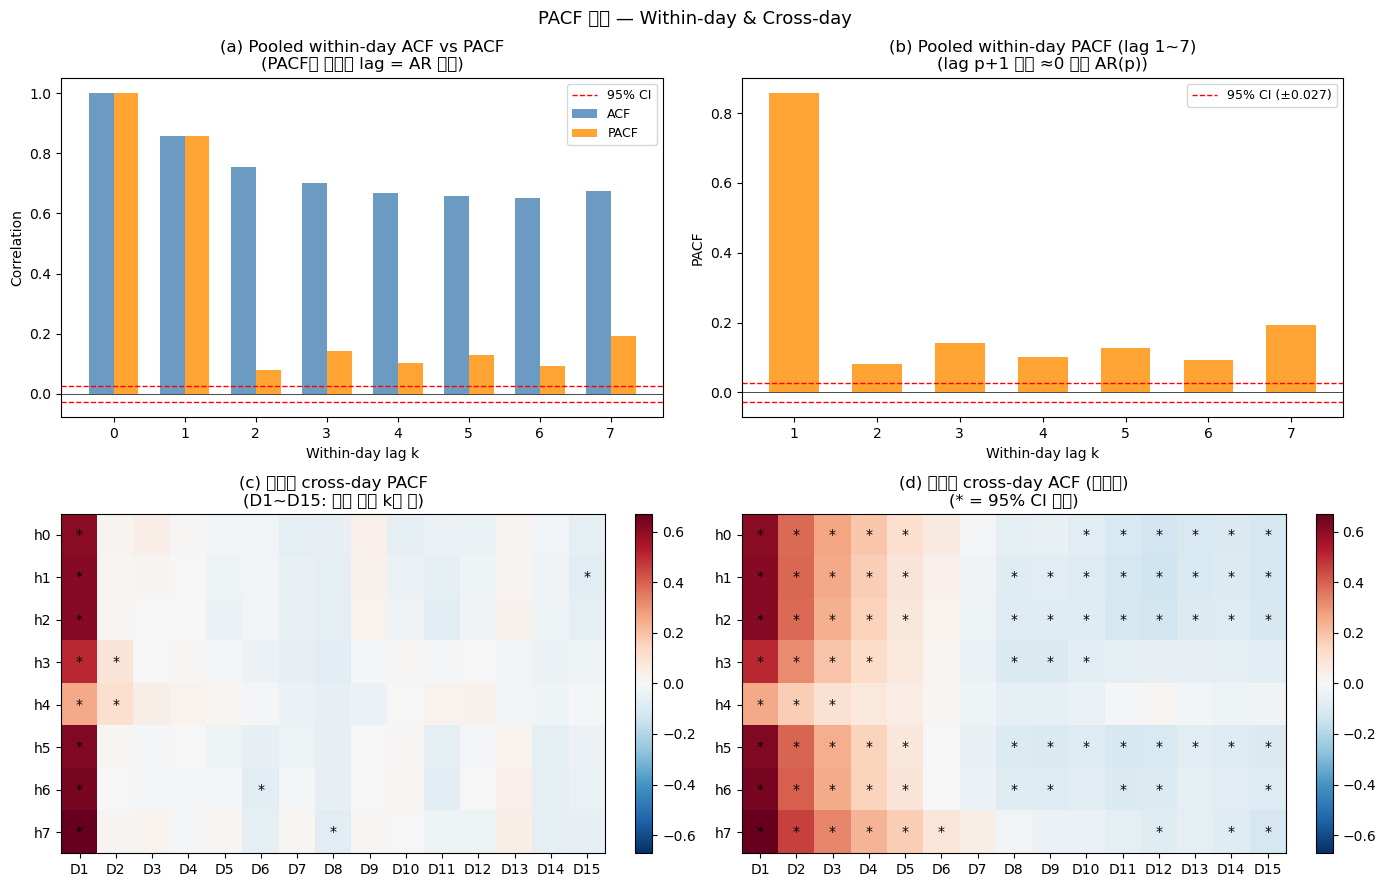

Saved: hourly_pacf_analysis.png


In [20]:
# ── Block 2b: 시각화 ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('PACF 분석 — Within-day & Cross-day', fontsize=13)

lags_w = np.arange(len(acf_vals))

# (a) Pooled within-day: ACF vs PACF 비교
ax = axes[0, 0]
width = 0.35
ax.bar(lags_w - width/2, acf_vals,  width, label='ACF',  color='steelblue', alpha=0.8)
ax.bar(lags_w + width/2, pacf_vals, width, label='PACF', color='darkorange', alpha=0.8)
ax.axhline( conf_w, ls='--', color='red', lw=1)
ax.axhline(-conf_w, ls='--', color='red', lw=1, label='95% CI')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Within-day lag k'); ax.set_ylabel('Correlation')
ax.set_title('(a) Pooled within-day ACF vs PACF\n(PACF가 끊기는 lag = AR 차수)')
ax.set_xticks(lags_w); ax.legend(fontsize=9)

# (b) Pooled PACF만 확대 (0, 1 제외)
ax = axes[0, 1]
ax.bar(lags_w[1:], pacf_vals[1:], color='darkorange', alpha=0.8, width=0.6)
ax.axhline( conf_w, ls='--', color='red', lw=1, label=f'95% CI (±{conf_w:.3f})')
ax.axhline(-conf_w, ls='--', color='red', lw=1)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Within-day lag k'); ax.set_ylabel('PACF')
ax.set_title('(b) Pooled within-day PACF (lag 1~7)\n(lag p+1 이후 ≈0 이면 AR(p))')
ax.set_xticks(lags_w[1:]); ax.legend(fontsize=9)

# (c) 슬롯별 cross-day PACF heatmap
ax = axes[1, 0]
show_lags = min(15, max_lag_cd)
data = slot_pacf_mat[:, 1:show_lags+1]
vmax = max(abs(np.nanmin(data)), abs(np.nanmax(data)))
im = ax.imshow(data, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(show_lags)); ax.set_xticklabels([f'D{k}' for k in range(1, show_lags+1)])
ax.set_yticks(range(n_slots)); ax.set_yticklabels([f'h{h}' for h in range(n_slots)])
ax.set_title(f'(c) 슬롯별 cross-day PACF\n(D1~D{show_lags}: 같은 슬롯 k일 전)')
plt.colorbar(im, ax=ax, fraction=0.046)
# 유의 표시
for h in range(n_slots):
    for j in range(show_lags):
        if abs(data[h, j]) > conf_cd:
            ax.text(j, h, '*', ha='center', va='center', fontsize=10, color='black')

# (d) 슬롯별 cross-day ACF heatmap (비교용)
ax = axes[1, 1]
data_acf = slot_acf_mat[:, 1:show_lags+1]
vmax2 = max(abs(np.nanmin(data_acf)), abs(np.nanmax(data_acf)))
im2 = ax.imshow(data_acf, cmap='RdBu_r', vmin=-vmax2, vmax=vmax2, aspect='auto')
ax.set_xticks(range(show_lags)); ax.set_xticklabels([f'D{k}' for k in range(1, show_lags+1)])
ax.set_yticks(range(n_slots)); ax.set_yticklabels([f'h{h}' for h in range(n_slots)])
ax.set_title(f'(d) 슬롯별 cross-day ACF (비교용)\n(* = 95% CI 초과)')
plt.colorbar(im2, ax=ax, fraction=0.046)
for h in range(n_slots):
    for j in range(show_lags):
        if abs(data_acf[h, j]) > conf_cd:
            ax.text(j, h, '*', ha='center', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.savefig(OUT_DIR / 'hourly_pacf_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: hourly_pacf_analysis.png')

---
## Block 3 — 왜 1과 2가 같은가 (요약) + PAR 모델

### 핵심 관계

$$\boxed{\hat{\gamma}(k) = \frac{1}{8-k}\sum_{h=0}^{7-k} \hat{C}[h,\, h+k]}$$

| | Block 1 | Block 2 |
|---|---|---|
| 계산 객체 | 8×8 공분산 행렬 $\hat{C}$ | lag별 pooled 평균 $\hat{\gamma}(k)$ |
| 정보량 | 더 많음 (대각선 내 분산 포함) | 요약값만 |
| Toeplitz 판단 | 가능 (대각선 내 std로) | 불가 (평균만) |
| 관계 | $\hat{\gamma}(k)$ = Block 1 대각선 평균 | Block 1의 부분 요약 |

**직관**: 하루의 8슬롯을 반복 실험 $n$번으로 봤을 때,
- Block 1: 각 슬롯 쌍 $(h_1, h_2)$의 공분산 → 8×8
- Block 2: "동일 시간 간격 $k$"의 쌍들을 모두 묶어서 하나의 숫자로 요약

---

### PAR (Periodic AR) 모델

각 슬롯 $h$마다 AR 계수가 다름 — within-day stationarity를 가정하지 않음.

**Within-day (W)**: 이전 슬롯에서 현재 슬롯 예측
$$Y[d, h] = \phi_{h,1}\, Y[d, h-1] + \phi_{h,2}\, Y[d, h-2] + \varepsilon_{d,h}, \quad h \geq 1$$

**Cross-day (D)**: 어제 같은 슬롯으로 현재 슬롯 예측 (16h 갭)
$$Y[d, 0] = \psi_0\, Y[d-1, 7] + \eta_{d}, \quad \text{(첫 슬롯)}$$
$$Y[d, h] = \phi_{h,W}\, Y[d, h-1] + \psi_h\, Y[d-1, h] + \varepsilon_{d,h}, \quad h \geq 1$$

계수 $\phi_{h,*}$, $\psi_h$는 슬롯 $h$마다 OLS로 따로 추정.

In [21]:
# ── Block 3: PAR 모델 ─────────────────────────────────────────────────────────

def fit_par_model(Y):
    """
    Periodic AR 모델: 슬롯 h마다 별도 OLS.

    슬롯 h=0: Y[d,0] = ψ_0 * Y[d-1, 7] + ε   (cross-day only)
    슬롯 h≥1: Y[d,h] = φ_h * Y[d, h-1]         (within W1)
                      + ψ_h * Y[d-1, h]         (cross-day D1 same slot)
                      + ε

    Returns DataFrame with slot, coefficients, R², AIC.
    """
    n_days, n_slots = Y.shape
    results = []

    for h in range(n_slots):
        if h == 0:
            # 첫 슬롯: 어제 마지막 슬롯(h=7)으로 예측
            y_vec  = Y[1:, 0]           # d=1..n-1
            x_prev = Y[:-1, 7]          # Y[d-1, 7]
            mask   = np.isfinite(y_vec) & np.isfinite(x_prev)
            y_, X_ = y_vec[mask], np.column_stack([np.ones(mask.sum()), x_prev[mask]])
            labels = ['intercept', 'ψ_0 (Y[d-1,7])']  # cross-day
        else:
            # h≥1: within W1 + cross-day D1 (same slot)
            y_vec    = Y[1:, h]          # d=1..n-1
            x_within = Y[1:, h-1]        # Y[d, h-1]   (within W1)
            x_cross  = Y[:-1, h]         # Y[d-1, h]   (cross-day D1)
            mask = (np.isfinite(y_vec) & np.isfinite(x_within) & np.isfinite(x_cross))
            y_, X_ = y_vec[mask], np.column_stack([
                np.ones(mask.sum()), x_within[mask], x_cross[mask]])
            labels = ['intercept', f'φ_{h} (within W1)', f'ψ_{h} (cross D1)']

        n_obs, k = len(y_), X_.shape[1]
        if n_obs <= k:
            continue

        coef, _, _, _ = np.linalg.lstsq(X_, y_, rcond=None)
        residuals = y_ - X_ @ coef
        sigma2    = np.mean(residuals**2)
        ss_tot    = np.var(y_) * n_obs
        r2        = 1 - np.sum(residuals**2) / ss_tot if ss_tot > 0 else np.nan
        aic       = n_obs * np.log(sigma2) + 2 * k if sigma2 > 0 else np.nan

        row = {'slot': h, 'n_obs': n_obs, 'k': k, 'R²': round(r2, 4), 'AIC': round(aic, 2)}
        for lbl, c in zip(labels, coef):
            row[lbl] = round(c, 5)
        results.append(row)

    return pd.DataFrame(results)


df_par = fit_par_model(Y)
print("PAR 모델 결과 (슬롯별 OLS):")
print(df_par.to_string(index=False))

PAR 모델 결과 (슬롯별 OLS):
 slot  n_obs  k     R²      AIC  intercept  ψ_0 (Y[d-1,7])  φ_1 (within W1)  ψ_1 (cross D1)  φ_2 (within W1)  ψ_2 (cross D1)  φ_3 (within W1)  ψ_3 (cross D1)  φ_4 (within W1)  ψ_4 (cross D1)  φ_5 (within W1)  ψ_5 (cross D1)  φ_6 (within W1)  ψ_6 (cross D1)  φ_7 (within W1)  ψ_7 (cross D1)
    0    725  2 0.4656  1187.77   -1.21940         0.69415              NaN             NaN              NaN             NaN              NaN             NaN              NaN             NaN              NaN             NaN              NaN             NaN              NaN             NaN
    1    725  3 0.9711  -944.83   -0.36622             NaN          0.96444         0.01286              NaN             NaN              NaN             NaN              NaN             NaN              NaN             NaN              NaN             NaN              NaN             NaN
    2    725  3 0.9759 -1078.79   -0.27531             NaN              NaN             NaN          0.98392 

Font 'default' does not have a glyph for '\uacc4' [U+acc4], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc218' [U+c218], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uacc4' [U+acc4], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc218' [U+c218], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc2ac' [U+c2ac], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ub86f' [U+b86f], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ubcc4' [U+bcc4], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uc124' [U+c124], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uba85' [U+ba85], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\ub825' [U+b825], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uacc4' [U+acc4], 

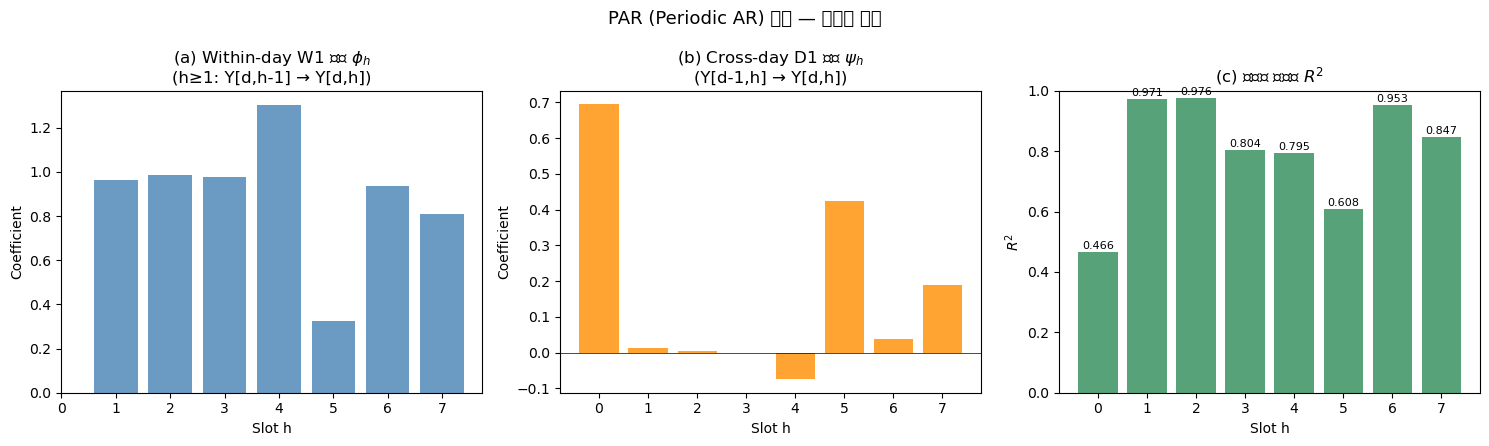

Saved: hourly_par_model.png


In [22]:
# ── Block 3: PAR 계수 시각화 ──────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('PAR (Periodic AR) 모델 — 슬롯별 계수', fontsize=13)

slots = df_par['slot'].values

# (a) Within-day φ 계수 (h≥1)
ax = axes[0]
phi_col = [c for c in df_par.columns if 'within' in c or 'φ' in c]
phi_vals = []
for _, row in df_par.iterrows():
    for col in phi_col:
        if col in row.index and pd.notna(row[col]):
            phi_vals.append((row['slot'], row[col]))
            break
    else:
        phi_vals.append((row['slot'], np.nan))

phi_s = [v[1] for v in phi_vals]
ax.bar(slots, phi_s, color='steelblue', alpha=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Slot h'); ax.set_ylabel('Coefficient')
ax.set_title('(a) Within-day W1 계수 $\\phi_h$\n(h≥1: Y[d,h-1] → Y[d,h])')
ax.set_xticks(slots)

# (b) Cross-day ψ 계수
ax = axes[1]
psi_col = [c for c in df_par.columns if 'cross' in c or 'ψ' in c]
psi_vals = []
for _, row in df_par.iterrows():
    for col in psi_col:
        if col in row.index and pd.notna(row[col]):
            psi_vals.append((row['slot'], row[col]))
            break
    else:
        psi_vals.append((row['slot'], np.nan))

psi_s = [v[1] for v in psi_vals]
ax.bar(slots, psi_s, color='darkorange', alpha=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Slot h'); ax.set_ylabel('Coefficient')
ax.set_title('(b) Cross-day D1 계수 $\\psi_h$\n(Y[d-1,h] → Y[d,h])')
ax.set_xticks(slots)

# (c) R² per slot
ax = axes[2]
ax.bar(slots, df_par['R²'].values, color='seagreen', alpha=0.8)
ax.set_ylim(0, 1)
ax.set_xlabel('Slot h'); ax.set_ylabel('$R^2$')
ax.set_title('(c) 슬롯별 설명력 $R^2$')
ax.set_xticks(slots)
for i, (s, r2) in enumerate(zip(slots, df_par['R²'].values)):
    ax.text(s, r2 + 0.01, f'{r2:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'hourly_par_model.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: hourly_par_model.png")

In [23]:
# ── 전체 요약 저장 ─────────────────────────────────────────────────────────────

df_toep.to_csv(OUT_DIR / 'hourly_toeplitz_check.csv', index=False)
df_acf.to_csv(OUT_DIR / 'hourly_pooled_acf.csv', index=False)
df_par.to_csv(OUT_DIR / 'hourly_par_results.csv', index=False)

print("모든 결과 저장 완료:")
print(f"  {OUT_DIR}/hourly_toeplitz_check.csv")
print(f"  {OUT_DIR}/hourly_pooled_acf.csv")
print(f"  {OUT_DIR}/hourly_par_results.csv")
print(f"  {OUT_DIR}/hourly_cov_toeplitz.png")
print(f"  {OUT_DIR}/hourly_pooled_acf.png")
print(f"  {OUT_DIR}/hourly_par_model.png")

모든 결과 저장 완료:
  /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/seasonal_ar/hourly_toeplitz_check.csv
  /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/seasonal_ar/hourly_pooled_acf.csv
  /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/seasonal_ar/hourly_par_results.csv
  /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/seasonal_ar/hourly_cov_toeplitz.png
  /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/seasonal_ar/hourly_pooled_acf.png
  /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/seasonal_ar/hourly_par_model.png
